#📊 Exploratory Data Analysis of DprE1 Inhibitors from ChEMBL


---




##🧪 Objective

The primary goal of this notebook is to perform Exploratory Data Analysis (EDA) on compounds targeting the enzyme DprE1 (Decaprenylphosphoryl-β-D-ribose 2’-epimerase), retrieved from the ChEMBL database. This preliminary analysis aims to provide a deeper understanding of the chemical and biological landscape of known inhibitors, which will guide subsequent machine learning (ML) modeling efforts.

## 🔍 Workflow Overview
### 1. Data Collection

- Query the ChEMBL database for compounds tested against DprE1.

- Retrieve relevant bioactivity data (e.g., IC₅₀ values) and molecular structures.

### 2. Activity Labeling

- Classify compounds as active or inactive based on bioactivity thresholds (e.g., IC₅₀ cutoff).

### 3. Physicochemical Property Analysis

- Compute and visualize distributions of key molecular descriptors:

  Molecular Weight (MW)
  
  LogP (lipophilicity)
  
  Topological Polar Surface Area (TPSA)
  
  Number of Hydrogen Bond Donors/Acceptors (HBD/HBA)
  
  Rotatable Bonds, etc.

### 4. Toxicity Prediction with DeepChem

- Predict potential toxicological profiles for all compounds using a pre-trained DeepChem model.
- Compute a *toxicity index* by aggregating predictions across 12 biological assays (e.g., NR-AR, SR-p53).
- Identify and visualize the *top 10 most toxic* and *top 10 least toxic compounds*.
- Explore the relationship between predicted toxicity and compound bioactivity (e.g., active vs. inactive vs. intermediate).
- Discuss implications for drug development, particularly the trade-offs between potency and safety.


### 5. Molecular Similarity Assessment

- Compute pairwise similarity metrics (e.g., Tanimoto similarity using fingerprints).
-
Investigate diversity within and between active/inactive classes.

## Import necessary libraries

In [1]:
%%capture
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install pandas mols2grid seaborn rdkit matplotlib useful_rdkit_utils scikit-learn ipywidgets

In [2]:
import pandas as pd
import mols2grid
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFMCS
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
import useful_rdkit_utils as uru
from IPython.core.display import HTML

## ChEMBL Database


In [3]:
! pip install chembl_webresource_client


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 5.0 MB/s eta 0:00:00


In [4]:
from chembl_webresource_client.new_client import new_client

# Target search for DprE1

DprE1 - Decaprenylphosphoryl-β-D-ribose 2′-epimerase - is a crucial enzyme involved in the biosynthesis of the mycobacterial cell wall, making it an attractive target for anti-tuberculosis drug discovery.

Since DprE1 is not targeted by current TB therapies, inhibitors of this enzyme offer a potential strategy to overcome multidrug-resistant (MDR) tuberculosis by providing new mechanisms to disrupt bacterial survival.  

We can search for inhibitors of this target present in the ChEMBL database


In [5]:
target = new_client.target
target_query = target.search('DprE1')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Mycobacterium smegmatis (strain ATCC 700084 / ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,16.0,False,CHEMBL3797019,"[{'accession': 'A0R607', 'component_descriptio...",SINGLE PROTEIN,246196
1,[],Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,16.0,False,CHEMBL3804751,"[{'accession': 'P9WJF1', 'component_descriptio...",SINGLE PROTEIN,83332


# Select and retrieve bioactivity data for DprE1


In [6]:
selected_target = targets.target_chembl_id[1]
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")
df = pd.DataFrame.from_dict(res)
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,16593124,[],CHEMBL3806437,Inhibition of recombinant Mycobacterium tuberc...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,9.6
1,None,None,19114375,[],CHEMBL4371323,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,nM,UO_0000065,None,70.0
2,None,None,19114408,[],CHEMBL4371330,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,0.12
3,None,None,19114409,[],CHEMBL4371330,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,0.041
4,None,None,19114410,[],CHEMBL4371330,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,0.072


In [7]:
df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='object')

In [8]:
df.standard_type.unique()

array(['IC50'], dtype=object)

In [9]:
df.to_csv('bioactivity_data.csv', index=False)

## Copying files to Google Drive

In [10]:
#from google.colab import drive
#drive.mount('/content/gdrive/', force_remount=True)

In [11]:
#! mkdir "/content/gdrive/My Drive/Colab Notebooks/data"
#! cp bioactivity_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"
#! ls "/content/gdrive/My Drive/Colab Notebooks/data"

In [12]:
! pwd

/content


In [13]:
! head bioactivity_data.csv

action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
,,16593124,[],CHEMBL3806437,Inhibition of recombinant Mycobacterium tuberculosis H37Rv DprE1 using FPR as substrate assessed as residual enzymatic activity preincubated for 10 mins followed by substrate addition by fluorescence assay,B,,,BAO_0000190,BAO_0000357,single protein format,C[C@H]1COC2(CCN(c3nc(=O)c4

# Handling missing data

In [14]:
df2 = df[df.standard_value.notna()]
df2

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,16593124,[],CHEMBL3806437,Inhibition of recombinant Mycobacterium tuberc...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,9.6
1,None,None,19114375,[],CHEMBL4371323,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,nM,UO_0000065,None,70.0
2,None,None,19114408,[],CHEMBL4371330,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,0.12
3,None,None,19114409,[],CHEMBL4371330,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,0.041
4,None,None,19114410,[],CHEMBL4371330,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,0.072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,"{'action_type': 'INHIBITOR', 'description': 'N...",None,24835015,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5144258,Inhibition of Mycobacterium tuberculosis wild ...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,18.87
143,"{'action_type': 'INHIBITOR', 'description': 'N...",None,24835016,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5144258,Inhibition of Mycobacterium tuberculosis wild ...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,11.54
144,"{'action_type': 'INHIBITOR', 'description': 'N...",None,24890105,[],CHEMBL5158266,Inhibition of recombinant Mycobacterium tuberc...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,ug ml-1,UO_0000274,None,0.1
145,"{'action_type': 'INHIBITOR', 'description': 'N...",None,25113034,[],CHEMBL5265610,Inhibition of Mycobacterium tuberculosis H37Rv...,B,None,None,BAO_0000190,...,Mycobacterium tuberculosis (strain ATCC 25618 ...,FAD-dependent decaprenylphosphoryl-beta-D-ribo...,83332,None,None,IC50,uM,UO_0000065,None,8.0


There is no missing values for this dataset


# Labeling compounds as active, inactive or intermediate

Compounds are categorized according to their IC₅₀ (half maximal inhibitory concentration) values as follows:

Active: IC₅₀ < 1,000 nM

Intermediate: 1,000 nM ≤ IC₅₀ ≤ 10,000 nM

Inactive: IC₅₀ > 10,000 nM

In [15]:
bioactivity_class = []
for i in df2.standard_value:
  if float(i) > 10000:
    bioactivity_class.append("inactive")
  elif float(i) <= 1000:
    bioactivity_class.append("active")
  else:
    bioactivity_class.append("intermediate")

In [16]:
#  Combine 'molecule_chembl_id', 'canonical_smiles', 'standard_value' and bioactivity class to a dataframe

selection = ['molecule_chembl_id', 'canonical_smiles', 'standard_value']
df3 = df2[selection]
bioactivity_series = pd.Series(bioactivity_class, name='bioactivity')
df4 = pd.concat([df3, bioactivity_series], axis=1)
df4

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity
0,CHEMBL3805705,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(N=[N+...,9600.0,intermediate
1,CHEMBL4437244,Cc1c(CCC(=O)N2CCCC2)c(=O)n2c([nH]c3ccccc32)c1C#N,70.0,active
2,CHEMBL4576609,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(C(F)(F)F...,120.0,active
3,CHEMBL1976041,COc1ccc(CNc2nc3cc(C(F)(F)F)ccc3nc2C(=O)O)cc1,41.0,active
4,CHEMBL1973996,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(F)cc1,72.0,active
...,...,...,...,...
142,CHEMBL5204853,N#Cc1ccc(C(=O)Nc2sccc2C(=O)NC(=O)OCC2CC2)cc1,18870.0,inactive
143,CHEMBL5172070,N#Cc1ccc(C(=O)Nc2sccc2C(=O)NC(=O)OCC2CC2)nc1,11540.0,inactive
144,CHEMBL5185220,COC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(S(=O)(=O)N2CCC...,0.1,active
145,CHEMBL4587211,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(-n5cc...,8000.0,intermediate


In [17]:
df4.to_csv('bioactivity_preprocessed.csv', index=False)

In [18]:
! cp bioactivity_preprocessed.csv "/content/gdrive/My Drive/Colab Notebooks/data"

cp: cannot create regular file '/content/gdrive/My Drive/Colab Notebooks/data': No such file or directory


In [19]:
! ls "/content/gdrive/My Drive/Colab Notebooks/data"

ls: cannot access '/content/gdrive/My Drive/Colab Notebooks/data': No such file or directory


# Exploratory Data Analysis

## Calculate Lipinski descriptors

Lipinski descriptors are a set of molecular properties commonly used to evaluate the drug-likeness of small molecules. These descriptors are based on Lipinski’s Rule of Five, a guideline developed by Christopher Lipinski to predict whether a compound is likely to be orally active in humans.

The key descriptors calculated include:

* Molecular Weight (MW) – should be ≤ 500 Daltons

* LogP (Partition coefficient) – should be ≤ 5, indicating lipophilicity

* Hydrogen Bond Donors (HBD) – should be ≤ 5

* Hydrogen Bond Acceptors (HBA) – should be ≤ 10

These descriptors are extremly important since they affect membrane permeability, solubility, and oral bioavailability. These properties are critical for determining whether a compound can be efficiently absorbed into the bloodstream, distributed to its target site, and exhibit favorable drug-like behavior. As such, Lipinski's Rule of Five serves as an early-stage filter in drug discovery, helping to eliminate molecules that are unlikely to be effective oral drugs due to poor absorption or permeability

In [20]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

def lipinski(smiles, verbose=False):
    moldata = []

    for a in smiles:
        mol = Chem.MolFromSmiles(a)
        moldata.append(mol)

    results = []  # Changed from 'descriptors' to 'results' to avoid name conflict

    for mol in moldata:
        if mol is not None:
            # Use RDKit's Descriptors module
            MolWt = Descriptors.MolWt(mol)
            MolLogP = Descriptors.MolLogP(mol)
            MolHBD = Descriptors.NumHDonors(mol)
            MolHBA = Descriptors.NumHAcceptors(mol)


            results.append([MolWt, MolLogP, MolHBD, MolHBA])
        else:
            results.append([None, None, None, None])

    columnNames = ["MW", "LogP", "HBD", "HBA"]
    return pd.DataFrame(results, columns=columnNames)

In [21]:
df_lipinski = lipinski(df4.canonical_smiles)

In [22]:
df_lipinski

,MW,LogP,HBD,HBA
0,427.408,4.34890,0,7
1,348.406,2.51590,1,4
2,415.293,4.97770,2,4
3,377.322,3.96750,2,5
4,365.286,4.09800,2,4
...,...,...,...,...
142,369.402,3.14848,2,6
143,370.390,2.54348,2,7
144,451.526,2.67120,2,7
145,451.470,4.19780,0,7


## Calculating Molecular Descriptors from SMILES

This code calculates a set of molecular descriptors for each compound in the DataFrame df4, which contains a column named 'canonical_smiles' with SMILES strings representing chemical structures.

For each molecule, the following descriptors are computed using RDKit:

* TPSA (Topological Polar Surface Area): Estimates the polarity of the molecule, useful for predicting drug absorption.

* Number of Rotatable Bonds: Indicates molecular flexibility, which can influence bioavailability.

* Ring Count: The number of rings present in the molecule.

* Heavy Atom Count: Number of non-hydrogen atoms, giving a sense of molecule size.

* Aromatic Proportion: The fraction of atoms in the molecule that are aromatic, which can influence molecule stability and interactions.

The script loops through each SMILES string, computes these descriptors, and stores them in new columns of the DataFrame df4.

In [23]:
from rdkit.Chem import rdMolDescriptors


# Assuming your DataFrame is called df and has a 'SMILES' column
# Example: df = pd.read_csv('your_file.csv')

# Prepare empty lists to store descriptor values
tpsa_list = []
rot_bonds_list = []
ring_count_list = []
heavy_atoms_list = []
aromatic_prop_list = []

# Loop through each SMILES in the DataFrame
for smi in df4['canonical_smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        tpsa = Descriptors.TPSA(mol)
        rot_bonds = Descriptors.NumRotatableBonds(mol)
        ring_count = rdMolDescriptors.CalcNumRings(mol)
        heavy_atoms = Descriptors.HeavyAtomCount(mol)
        aromatic_atoms = sum(1 for atom in mol.GetAtoms() if atom.GetIsAromatic())
        total_atoms = mol.GetNumAtoms()
        aromatic_proportion = aromatic_atoms / total_atoms if total_atoms else 0
    else:
        tpsa = rot_bonds = ring_count = heavy_atoms = aromatic_proportion = None

    # Append to lists
    tpsa_list.append(tpsa)
    rot_bonds_list.append(rot_bonds)
    ring_count_list.append(ring_count)
    heavy_atoms_list.append(heavy_atoms)
    aromatic_prop_list.append(aromatic_proportion)

# Add new columns to your DataFrame
df4['TPSA'] = tpsa_list
df4['RotatableBonds'] = rot_bonds_list
df4['RingCount'] = ring_count_list
df4['HeavyAtoms'] = heavy_atoms_list
df4['AromaticProportion'] = aromatic_prop_list
df4


,molecule_chembl_id,canonical_smiles,standard_value,bioactivity,TPSA,RotatableBonds,RingCount,HeavyAtoms,AromaticProportion
0,CHEMBL3805705,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(N=[N+...,9600.0,intermediate,100.42,2,4,29,0.344828
1,CHEMBL4437244,Cc1c(CCC(=O)N2CCCC2)c(=O)n2c([nH]c3ccccc32)c1C#N,70.0,active,81.37,3,4,26,0.500000
2,CHEMBL4576609,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(C(F)(F)F...,120.0,active,75.11,4,3,29,0.551724
3,CHEMBL1976041,COc1ccc(CNc2nc3cc(C(F)(F)F)ccc3nc2C(=O)O)cc1,41.0,active,84.34,5,3,27,0.592593
4,CHEMBL1973996,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(F)cc1,72.0,active,75.11,4,3,26,0.615385
...,...,...,...,...,...,...,...,...,...
142,CHEMBL5204853,N#Cc1ccc(C(=O)Nc2sccc2C(=O)NC(=O)OCC2CC2)cc1,18870.0,inactive,108.29,5,3,26,0.423077
143,CHEMBL5172070,N#Cc1ccc(C(=O)Nc2sccc2C(=O)NC(=O)OCC2CC2)nc1,11540.0,inactive,121.18,5,3,26,0.423077
144,CHEMBL5185220,COC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(S(=O)(=O)N2CCC...,0.1,active,121.88,5,3,30,0.366667
145,CHEMBL4587211,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(-n5cc...,8000.0,intermediate,56.59,2,5,31,0.483871


In [24]:
# Combine the DataFrames
df_combined = pd.concat([df4,df_lipinski], axis=1)
print(df_combined.columns)
df_combined.head()

Index(['molecule_chembl_id', 'canonical_smiles', 'standard_value',
       'bioactivity', 'TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtoms',
       'AromaticProportion', 'MW', 'LogP', 'HBD', 'HBA'],
      dtype='object')


,molecule_chembl_id,canonical_smiles,standard_value,bioactivity,TPSA,RotatableBonds,RingCount,HeavyAtoms,AromaticProportion,MW,LogP,HBD,HBA
0,CHEMBL3805705,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(N=[N+...,9600.0,intermediate,100.42,2,4,29,0.344828,427.408,4.3489,0,7
1,CHEMBL4437244,Cc1c(CCC(=O)N2CCCC2)c(=O)n2c([nH]c3ccccc32)c1C#N,70.0,active,81.37,3,4,26,0.500000,348.406,2.5159,1,4
2,CHEMBL4576609,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(C(F)(F)F...,120.0,active,75.11,4,3,29,0.551724,415.293,4.9777,2,4
3,CHEMBL1976041,COc1ccc(CNc2nc3cc(C(F)(F)F)ccc3nc2C(=O)O)cc1,41.0,active,84.34,5,3,27,0.592593,377.322,3.9675,2,5
4,CHEMBL1973996,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(F)cc1,72.0,active,75.11,4,3,26,0.615385,365.286,4.0980,2,4


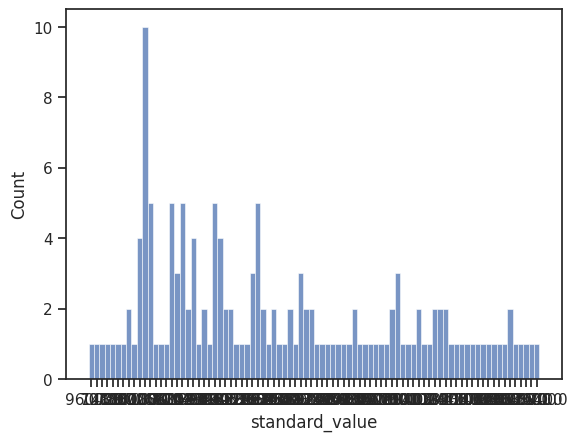

In [25]:
sns.set(style='ticks')
ax = sns.histplot(df_combined["standard_value"])

As we can observe, using IC50 directly can be problematic

# Convert IC50 to pIC50

pIC₅₀ is calculated as –log₁₀(IC₅₀), converting exponentially scaled concentration values into a linear, unitless metric; this normalizes skewed data distributions, making them more suitable for statistical analysis and comparison. Because lower IC₅₀ values indicate higher potency, the negative logarithm in pIC₅₀ inverts this relationship: higher pIC₅₀ values reflect stronger bioactivity. This allows for a clearer, more intuitive interpretation across compounds.

In [26]:
# Ensure standard_value is numeric
df_combined['standard_value'] = pd.to_numeric(df_combined['standard_value'], errors='coerce')

# Drop rows with missing standard_value
df_combined = df_combined.dropna(subset=['standard_value'])

# Calculate pIC50
df_combined['pIC50'] = -np.log10(df_combined['standard_value'] * 1e-9)

# Check result
print(df_combined[['standard_value', 'pIC50']].head())

   standard_value     pIC50
0          9600.0  5.017729
1            70.0  7.154902
2           120.0  6.920819
3            41.0  7.387216
4            72.0  7.142668


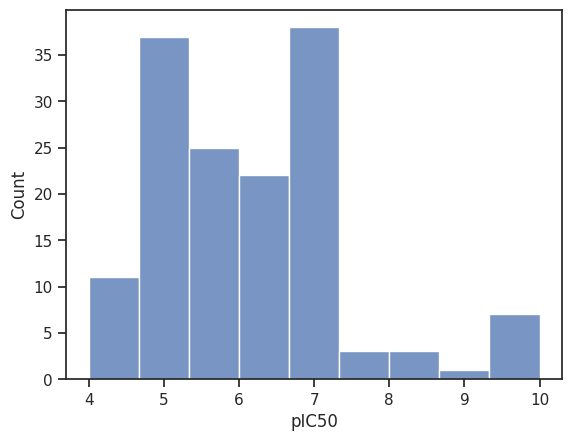

In [27]:
ax = sns.histplot(df_combined["pIC50"])

This histogram is extremely usefull to see the distribution of pIC50 in our dataset. We can observe that most compounds have a pIC50 between 5 and 7. Even more helpfull would be to include the bioactivity classes to visualize the distribution of pIC50 per class.

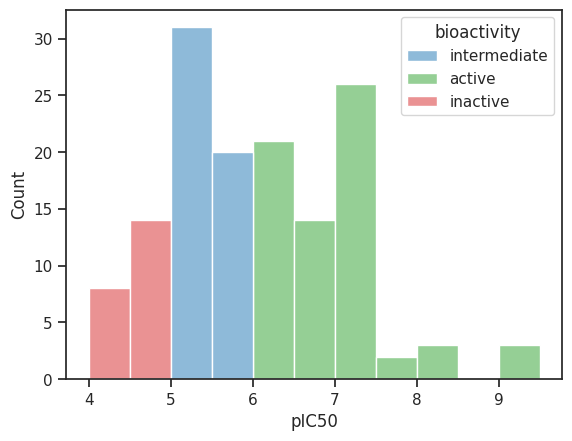

In [28]:
custom_palette = {
    'active': '#2ca02c',
    'inactive': '#d62728',
    'intermediate': '#1f77b4'
}
ax = sns.histplot(x="pIC50", hue="bioactivity", palette=custom_palette, data=df_combined, bins=np.arange(4, 10, 0.5))

This histogram also indicates that we considerable have less inactive compounds in comparison with the active ones. We can confirm by plotting the frequency per bioactivity class.

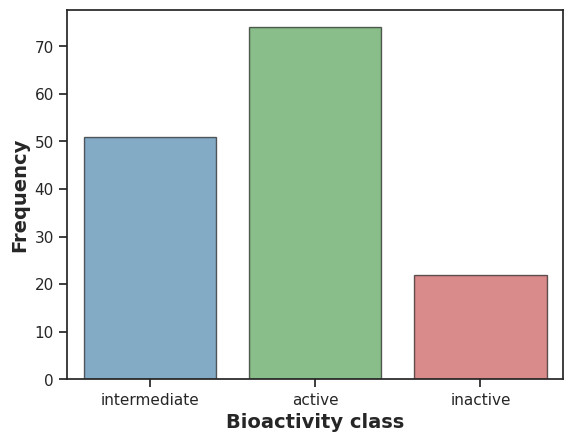

In [29]:
custom_palette = {
    'active': '#2ca02c',
    'inactive': '#d62728',
    'intermediate': '#1f77b4'
}

sns.countplot(x="bioactivity", data=df_combined, palette=custom_palette, edgecolor='black', hue="bioactivity", alpha=0.6)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.savefig('plot_bioactivity_class.pdf')

The bar plot above shows the distribution of compounds across three bioactivity classes: active, intermediate, and inactive. It is clear that the dataset is imbalanced, with a majority of compounds labeled as active, followed by intermediate, and a significantly smaller number labeled as inactive.

This imbalance is crucial to consider when building a machine learning (ML) classifier. Without proper handling, the model may become biased toward the majority class (active), resulting in:

* Over-optimistic performance metrics, especially if accuracy is used alone.

* Poor generalization for minority classes, particularly the inactive compounds, which are underrepresented.

* Reduced utility in real-world applications, where identifying inactive compounds might be just as important as detecting active ones.

To address this, techniques such as resampling (over-/under-sampling), class weighting, or using specialized algorithms like SMOTE or ensemble methods should be considered. Additionally, evaluation metrics such as F1-score, precision-recall curves, or balanced accuracy are better suited to assess model performance in imbalanced scenarios.

In [30]:
df_combined.to_csv("bioactivity_descriptors.csv")

In [31]:
df_combined.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity,TPSA,RotatableBonds,RingCount,HeavyAtoms,AromaticProportion,MW,LogP,HBD,HBA,pIC50
0,CHEMBL3805705,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(N=[N+...,9600.0,intermediate,100.42,2,4,29,0.344828,427.408,4.3489,0,7,5.017729
1,CHEMBL4437244,Cc1c(CCC(=O)N2CCCC2)c(=O)n2c([nH]c3ccccc32)c1C#N,70.0,active,81.37,3,4,26,0.500000,348.406,2.5159,1,4,7.154902
2,CHEMBL4576609,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(C(F)(F)F...,120.0,active,75.11,4,3,29,0.551724,415.293,4.9777,2,4,6.920819
3,CHEMBL1976041,COc1ccc(CNc2nc3cc(C(F)(F)F)ccc3nc2C(=O)O)cc1,41.0,active,84.34,5,3,27,0.592593,377.322,3.9675,2,5,7.387216
4,CHEMBL1973996,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(F)cc1,72.0,active,75.11,4,3,26,0.615385,365.286,4.0980,2,4,7.142668


In [32]:
! cp bioactivity_descriptors.csv "/content/gdrive/My Drive/Colab Notebooks/data"
! ls "/content/gdrive/My Drive/Colab Notebooks/data"

cp: cannot create regular file '/content/gdrive/My Drive/Colab Notebooks/data': No such file or directory
ls: cannot access '/content/gdrive/My Drive/Colab Notebooks/data': No such file or directory


# Box plots

A box plot, or box-and-whisker plot, is a standardized way to display the distribution of data based on five summary statistics:

Median (Q2) – the line inside the box → This represents the middle value of the dataset.

1st Quartile (Q1) – the bottom edge of the box → 25% of the data falls below this value.

3rd Quartile (Q3) – the top edge of the box → 75% of the data falls below this value.

Interquartile Range (IQR) – the height of the box → IQR=Q3−Q1, which contains the middle 50% of the data.

Whiskers – lines extending from the box → Typically extend to 1.5 × IQR beyond Q1 and Q3 to include most of the remaining data points.

Outliers – dots outside the whiskers → These represent values that are unusually high or low and may indicate experimental variability, measurement errors, or biologically significant phenomena

<Figure size 550x550 with 0 Axes>

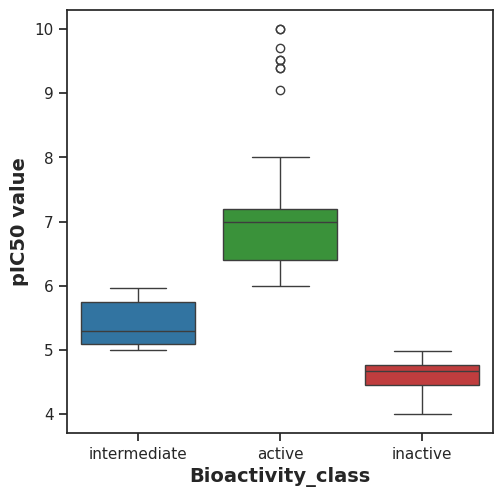

In [33]:
plt.figure(figsize=(5.5, 5.5))
plt.figure(figsize=(5.5, 5.5))
custom_palette = {
    'active': '#2ca02c',
    'inactive': '#d62728',
    'intermediate': '#1f77b4'
}
sns.boxplot(x='bioactivity', y='pIC50', hue='bioactivity', palette=custom_palette, data=df_combined)
plt.xlabel('Bioactivity_class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')
plt.savefig('boxplot_pIC50.pdf')

From the box plot we can see:

* Active Compounds: These show the highest median pIC50 values (around 7), indicating strong bioactivity. The range is also broader, suggesting greater variability. Several outliers above 9 highlight compounds with exceptionally high potency.

* Intermediate Compounds: These have a median pIC50 value around 5.3, with a moderately narrow IQR. Their activity lies between active and inactive compounds, as expected.

* Inactive Compounds: These exhibit the lowest pIC50 values, with a median close to 4.7 and a narrow IQR, suggesting consistent low activity among these compounds.

**Conclusion**: The clear separation of medians and IQRs among the three classes supports the categorization of compounds by bioactivity. The plot effectively demonstrates that pIC50 is a useful metric for distinguishing between active, intermediate, and inactive compounds

## Scatter plot of MW versus LogP

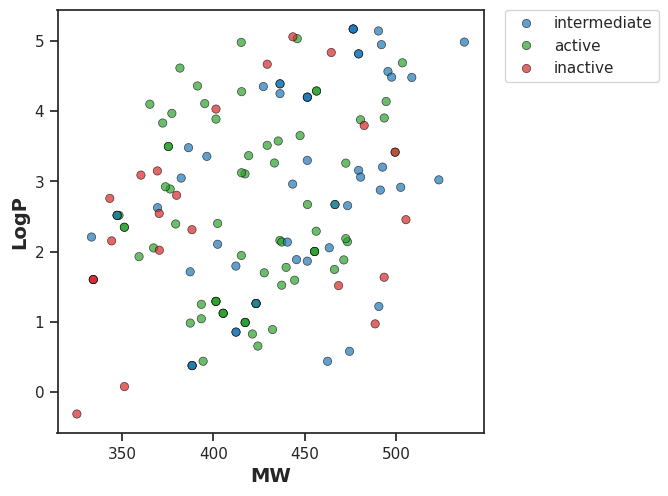

In [34]:
plt.figure(figsize=(5.5, 5.5))
custom_palette = {
    'active': '#2ca02c',
    'inactive': '#d62728',
    'intermediate': '#1f77b4'
}
sns.scatterplot(x='MW', y='LogP', data=df_combined, hue="bioactivity", palette=custom_palette, edgecolor='black', alpha=0.7)
plt.xlabel("MW", fontsize=14, fontweight="bold")
plt.ylabel("LogP", fontsize=14, fontweight="bold")
plt.legend(bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')


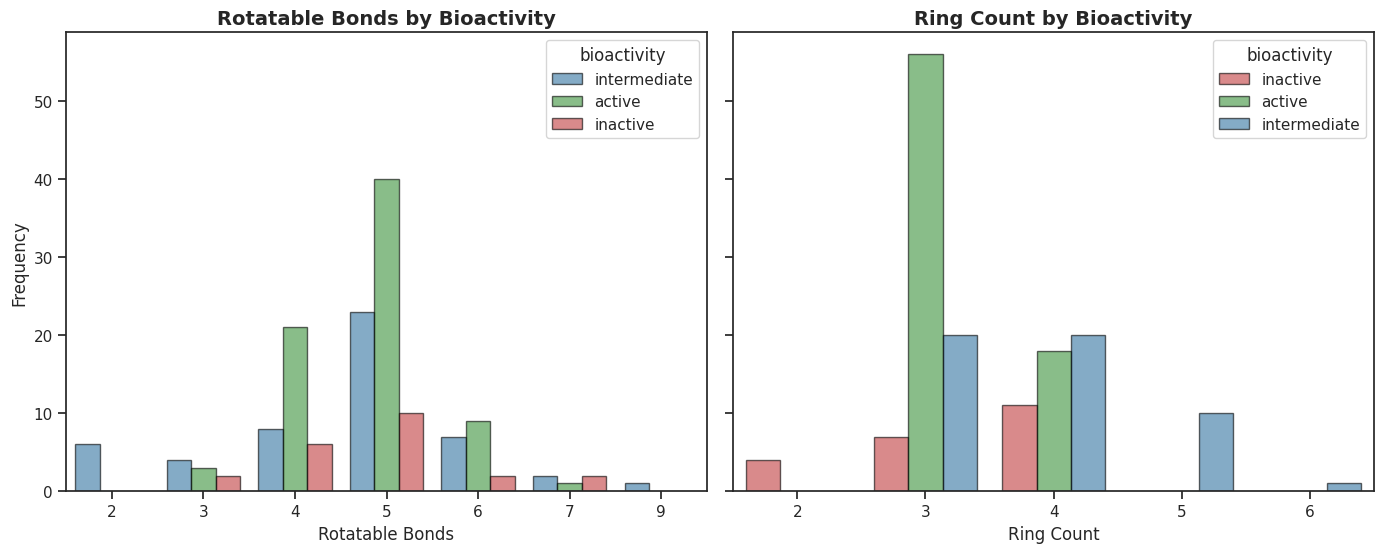

In [35]:
import seaborn as sns

# Set up your custom color palette
custom_palette = {
    'active': '#2ca02c',
    'inactive': '#d62728',
    'intermediate': '#1f77b4'
}

# Create a side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot 1: RotatableBonds
sns.countplot(
    data=df_combined,
    x="RotatableBonds",
    hue="bioactivity",
    palette=custom_palette,
    edgecolor='black',
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Rotatable Bonds by Bioactivity', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rotatable Bonds', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot 2: RingCount
sns.countplot(
    data=df_combined,
    x="RingCount",
    hue="bioactivity",
    palette=custom_palette,
    edgecolor='black',
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Ring Count by Bioactivity', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ring Count', fontsize=12)
axes[1].set_ylabel('')  # Hide duplicate ylabel


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('rotatable_ringcount_by_bioactivity.pdf')
plt.show()


**Topological Polar Surface Area** (TPSA) is a molecular descriptor that estimates the surface area occupied by polar atoms (typically oxygen and nitrogen) and their attached hydrogens. It reflects a molecule’s polarity and hydrogen bonding capacity, which are key factors influencing drug absorption, permeability, and bioavailability.

Plotting TPSA against **Hydrogen Bond Acceptors** (HBA) and **Hydrogen Bond Donors** (HBD) helps visualize how these functional groups contribute to the molecule’s overall polarity. Additionally, comparing TPSA with Heavy Atom Count reveals how molecular size correlates with polarity. Together, these plots provide insights into the physicochemical properties affecting drug-likeness and pharmacokinetics.

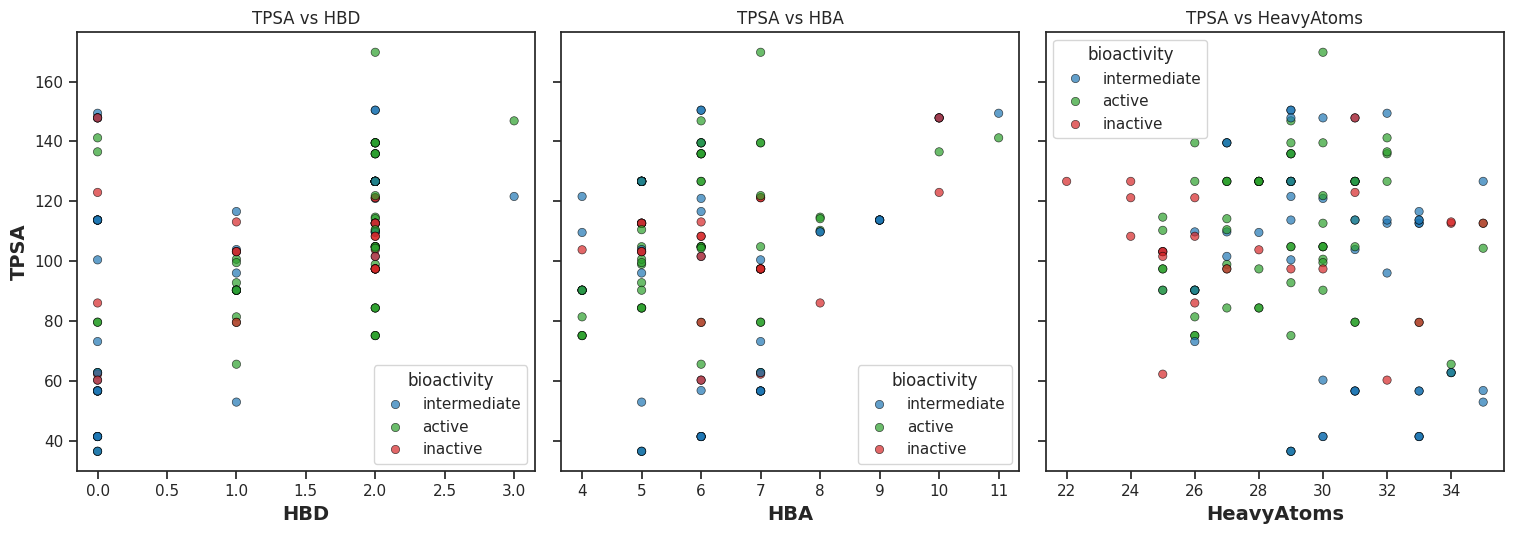

In [36]:
custom_palette = {
    'active': '#2ca02c',
    'inactive': '#d62728',
    'intermediate': '#1f77b4'
}

# Create figure and three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)  # bigger width for 3 plots

# Scatterplot 1: TPSA vs HBD
sns.scatterplot(
    x='HBD', y='TPSA', data=df_combined,
    hue='bioactivity', palette=custom_palette,
    edgecolor='black', alpha=0.7, ax=axes[0]
)
axes[0].set_xlabel('HBD', fontsize=14, fontweight='bold')
axes[0].set_ylabel('TPSA', fontsize=14, fontweight='bold')
axes[0].set_title('TPSA vs HBD')

# Scatterplot 2: TPSA vs HBA
sns.scatterplot(
    x='HBA', y='TPSA', data=df_combined,
    hue='bioactivity', palette=custom_palette,
    edgecolor='black', alpha=0.7, ax=axes[1]
)
axes[1].set_xlabel('HBA', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')  # Hide ylabel here because shared with left plot
axes[1].set_title('TPSA vs HBA')

# Scatterplot 3: TPSA vs HeavyAtoms
sns.scatterplot(
    x='HeavyAtoms', y='TPSA', data=df_combined,
    hue='bioactivity', palette=custom_palette,
    edgecolor='black', alpha=0.7, ax=axes[2]  # <--- use axes[2] here
)
axes[2].set_xlabel('HeavyAtoms', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_title('TPSA vs HeavyAtoms')



plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on right for legend
plt.savefig('tpsa_vs_hbd_hba_heavyatoms.pdf')
plt.show()


These graphics are not easy to visualize but we can observe some trends such as most active compounds have at least 1 hydrogen bond donor (HBD), with most compounds having 1 or 2 HBD. Considering the hydrogen bond acceptors (HBA), we can also observe that most active compounds have more than 4 HBA. Interestingly, the amount of heavy atoms seems to matter slightly since we only have active compounds with more than 24. Moreover, we can also observe a tendency regarding the TPSA and the activity, with the active compounds having at least more than 60 Å.

We can observe the means, max and min values for each property and check tendencies in the bioactivity classes, which will be important to identify which features vary most between active and inactive compounds.

In [37]:
from tabulate import tabulate

# Features of interest
features = ['TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtoms',
            'AromaticProportion', 'MW', 'LogP', 'HBD', 'HBA']

# Compute summary stats per bioactivity class (no quantiles)
summary = (
    df_combined
    .groupby("bioactivity")[features]
    .agg(['mean', 'std', 'min', 'median', 'max'])
)

# Flatten multi-level columns
summary.columns = ['_'.join(col).strip() for col in summary.columns]

# Round for clarity
summary = summary.round(2)

# Print nicely
print(tabulate(summary, headers='keys', tablefmt='fancy_grid'))

# Save to CSV
summary.to_csv("bioactivity_summary_clean.csv")


╒═══════════════╤═════════════╤════════════╤════════════╤═══════════════╤════════════╤═══════════════════════╤══════════════════════╤══════════════════════╤═════════════════════════╤══════════════════════╤══════════════════╤═════════════════╤═════════════════╤════════════════════╤═════════════════╤═══════════════════╤══════════════════╤══════════════════╤═════════════════════╤══════════════════╤═══════════════════════════╤══════════════════════════╤══════════════════════════╤═════════════════════════════╤══════════════════════════╤═══════════╤══════════╤══════════╤═════════════╤══════════╤═════════════╤════════════╤════════════╤═══════════════╤════════════╤════════════╤═══════════╤═══════════╤══════════════╤═══════════╤════════════╤═══════════╤═══════════╤══════════════╤═══════════╕
│ bioactivity   │   TPSA_mean │   TPSA_std │   TPSA_min │   TPSA_median │   TPSA_max │   RotatableBonds_mean │   RotatableBonds_std │   RotatableBonds_min │   RotatableBonds_median │   RotatableBonds_max │ 

This created a gigantic table, however, it is not easy to interprete. One good alternative is to create heatmaps.

## Feature Differences by Bioactivity
We can analyze how different molecular features vary across bioactivity classes (e.g., active, inactive, intermediate) using standardized scores (Z-scores). It follows three main steps:

✅ **Step 1: Compute Mean Feature Values by Bioactivity Class**

Calculates the average value of each molecular feature within each class.

✅ **Step 2: Standardize Feature Values Using Z-score Normalization**

Standardizes each feature column-wise so they are on the same scale.

A Z-score tells how far a class mean is from the overall feature mean:

* \> 0: Higher than average

* < 0: Lower than average

* 0: Equal to average

✅ **Step 3: Visualize Differences as a Heatmap**

Plots a heatmap with color gradients to show how features differ per class.

Color:

Red = Higher-than-average values

Blue = Lower-than-average values



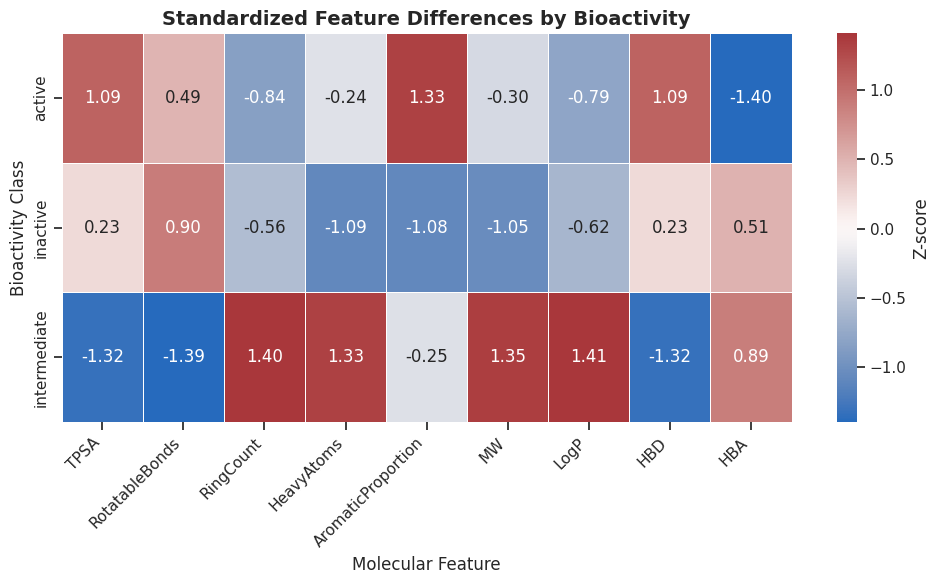

In [38]:
from scipy.stats import zscore

# Step 1: Compute per-class mean feature values
features = ['TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtoms',
            'AromaticProportion', 'MW', 'LogP', 'HBD', 'HBA']

mean_df = df_combined.groupby("bioactivity")[features].mean()

# Step 2: Apply z-score normalization per feature (i.e., column-wise)
zscore_df = mean_df.apply(zscore, axis=0)

# Step 3: Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    zscore_df,
    annot=True,
    cmap="vlag",      # good diverging colormap
    center=0,         # zero-centered
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'}
)

plt.title("Standardized Feature Differences by Bioactivity", fontsize=14, fontweight='bold')
plt.ylabel("Bioactivity Class")
plt.xlabel("Molecular Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


This analysis helps identify which molecular features are most associated with biological activity. For instance:

Active compounds tend to have:

* Higher TPSA (polarity)
* More heavy atoms
* More H-bond donors
* Lower lipophilicity (LogP)

Inactive compounds are:

* Less aromatic
* More flexible (more rotatable bonds)
* Intermediate compounds are:
* Larger, ring-rich, more lipophilic
* Low in polarity and H-bond capacity



Now, from these features, it would be important to know which ones vary the most

In [39]:
from scipy.stats import sem

# Filter dataset
df_filtered = df_combined[df_combined['bioactivity'].isin(['active', 'inactive'])]

# Define all features to consider
features = ['TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtoms',
            'AromaticProportion', 'MW', 'LogP', 'HBD', 'HBA']

# Calculate mean per bioactivity class
mean_df = df_filtered.groupby('bioactivity')[features].mean()

# Calculate absolute difference between active and inactive
diff = (mean_df.loc['active'] - mean_df.loc['inactive']).abs()

# Sort features by difference descending
diff_sorted = diff.sort_values(ascending=False)

# Select top 3 features
top_n = 3
top_features = diff_sorted.head(top_n).index.tolist()

print("Top varying features:", top_features)


Top varying features: ['MW', 'TPSA', 'HeavyAtoms']


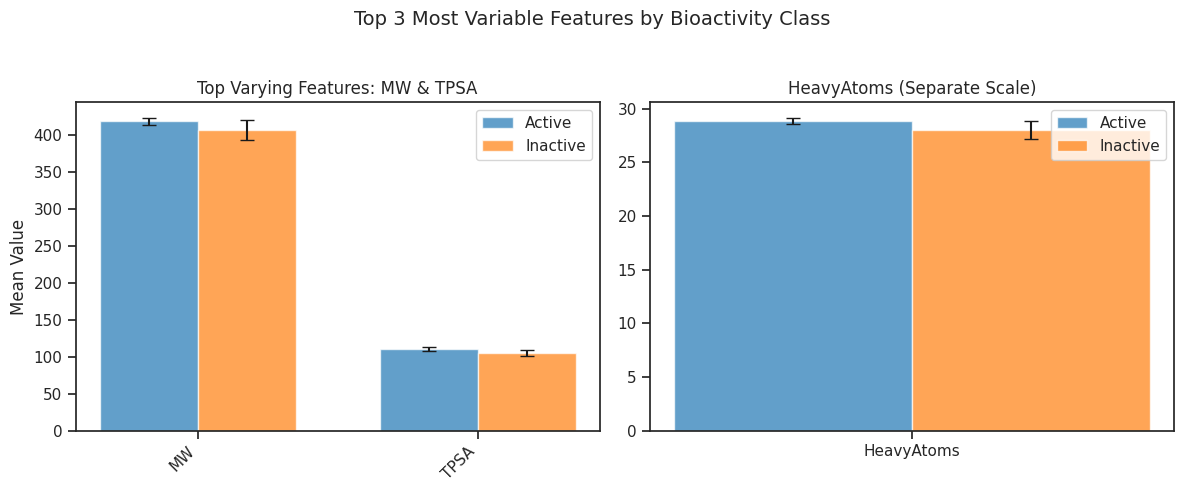

In [40]:
# Define features explicitly
top_features_main = ['MW', 'TPSA']
top_feature_heavy = 'HeavyAtoms'

# Recalculate means and SEM for selected features
features = top_features_main + [top_feature_heavy]
mean_df = df_filtered.groupby('bioactivity')[features].mean()
sem_df = df_filtered.groupby('bioactivity')[features].agg(lambda x: sem(x, nan_policy='omit'))

# Setup subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
width = 0.35

# --- Plot 1: MW and TPSA ---
x_main = np.arange(len(top_features_main))
axes[0].bar(x_main - width/2, mean_df.loc['active', top_features_main], width,
            yerr=sem_df.loc['active', top_features_main], capsize=5,
            label='Active', color='tab:blue', alpha=0.7)
axes[0].bar(x_main + width/2, mean_df.loc['inactive', top_features_main], width,
            yerr=sem_df.loc['inactive', top_features_main], capsize=5,
            label='Inactive', color='tab:orange', alpha=0.7)
axes[0].set_xticks(x_main)
axes[0].set_xticklabels(top_features_main, rotation=45, ha='right')
axes[0].set_title('Top Varying Features: MW & TPSA')
axes[0].set_ylabel('Mean Value')
axes[0].legend()

# --- Plot 2: HeavyAtoms ---
x_heavy = np.array([0])
axes[1].bar(x_heavy - width/2, mean_df.loc['active', top_feature_heavy], width,
            yerr=sem_df.loc['active', top_feature_heavy], capsize=5,
            label='Active', color='tab:blue', alpha=0.7)
axes[1].bar(x_heavy + width/2, mean_df.loc['inactive', top_feature_heavy], width,
            yerr=sem_df.loc['inactive', top_feature_heavy], capsize=5,
            label='Inactive', color='tab:orange', alpha=0.7)
axes[1].set_xticks(x_heavy)
axes[1].set_xticklabels([top_feature_heavy])
axes[1].set_title('HeavyAtoms (Separate Scale)')
axes[1].legend()

plt.suptitle('Top 3 Most Variable Features by Bioactivity Class', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


While there appears to be a visual difference in the mean values for these features between the two classes, the error bars (representing the standard deviation) suggest that the differences may not be statistically significant. This overlap indicates that observed differences could be due to random variation, and not necessarily due to true differences in the underlying distributions.

To formally test for statistical significance, we will apply the Mann-Whitney U test, a non-parametric statistical test.

## Statistical analysis using the Mann-Whitney U test
The Mann-Whitney U test, also known as the Wilcoxon rank-sum test, is a non-parametric statistical method used to evaluate whether there is a significant difference in the distribution of a continuous or ordinal variable between two independent groups. Unlike parametric tests such as the t-test, it does not assume normality of the data, making it particularly well-suited for datasets that are skewed, contain outliers, or violate homoscedasticity.

In this study, the Mann-Whitney U test is employed to assess and compare the distributions of various molecular or structural features across different bioactivity classes: *active vs. inactive*, *intermediate vs. active*, and *intermediate vs. inactive*. By ranking the combined samples and evaluating the difference in rank sums between groups, the test determines whether the central tendencies of the distributions differ significantly.

This method is advantageous in bioactivity modeling because many molecular descriptors exhibit non-normal distributions due to the diverse chemical and biological nature of compounds. Additionally, the test is robust to unequal sample sizes and can detect subtle yet consistent shifts in feature distributions between activity classes.

In [41]:
from numpy.random import seed
from numpy.random import randn
from scipy.stats import mannwhitneyu

from scipy.stats import mannwhitneyu

def mannwhitney_summary(descriptor, alpha=0.05):
    groups = {
        "active": df_combined[df_combined.bioactivity == "active"][descriptor].dropna(),
        "inactive": df_combined[df_combined.bioactivity == "inactive"][descriptor].dropna(),
        "intermediate": df_combined[df_combined.bioactivity == "intermediate"][descriptor].dropna()
    }

    results = []
    pairs = [("active", "inactive"), ("active", "intermediate"), ("intermediate", "inactive")]

    for g1, g2 in pairs:
        stat, p = mannwhitneyu(groups[g1], groups[g2], alternative='two-sided')
        interpretation = "significant" if p < alpha else "not significant"
        results.append({
            "Descriptor": descriptor,
            "Group 1": g1,
            "Group 2": g2,
            "U-statistic": stat,
            "p-value": p,
            "alpha": alpha,
            "Interpretation": interpretation
        })

    return pd.DataFrame(results)



In [42]:
import pandas as pd

descriptors = ["pIC50", "LogP", "MW", "HBD", "HBA", "TPSA", 'RotatableBonds', 'RingCount', 'HeavyAtoms',
            'AromaticProportion']

all_results = []

for desc in descriptors:
    df_res = mannwhitney_summary(desc)
    df_res['Comparison'] = df_res['Group 1'] + " vs " + df_res['Group 2']

    # Create an interpretation string combining significance and p-value nicely formatted
    df_res['Interpretation_summary'] = df_res.apply(
        lambda row: f"{row['Interpretation']} (p={row['p-value']:.3g})", axis=1
    )

    all_results.append(df_res)

df_results = pd.concat(all_results, ignore_index=True)

# Pivot using the Interpretation_summary instead of raw p-values
wide_interpretation = (
    df_results
    .pivot(index='Descriptor', columns='Comparison', values='Interpretation_summary')
)

# Optional: rename columns to start with "int_"
wide_interpretation.columns = [f"int_{col}" for col in wide_interpretation.columns]

wide_interpretation.to_csv("mannwhitney_interpretations.csv")

display(wide_interpretation)

,int_active vs inactive,int_active vs intermediate,int_intermediate vs inactive
Descriptor,,,
AromaticProportion,not significant (p=0.193),not significant (p=0.0667),not significant (p=0.99)
HBA,significant (p=0.048),significant (p=0.00896),not significant (p=0.936)
HBD,not significant (p=0.115),significant (p=5.6e-07),significant (p=0.0233)
HeavyAtoms,not significant (p=0.153),significant (p=0.000854),significant (p=0.00886)
LogP,not significant (p=0.787),not significant (p=0.0613),not significant (p=0.241)
MW,not significant (p=0.236),significant (p=0.00089),significant (p=0.0187)
RingCount,not significant (p=0.311),significant (p=4.82e-06),significant (p=0.0386)
RotatableBonds,not significant (p=0.958),not significant (p=0.745),not significant (p=0.795)
TPSA,not significant (p=0.243),not significant (p=0.0544),not significant (p=0.618)


From these results, we can conclude the following:

* **HBA** : Significantly different between active and inactive (p = 0.048), and also between active and intermediate (p = 0.00896), but not between intermediate and inactive. This suggests that active compounds tend to have higher or more distinct HBA profiles than both other groups.

* **HBD** : While not significantly different between active and inactive (p = 0.115), it shows strong differences involving intermediates (active vs intermediate: p ≈ 5.6e-07; intermediate vs inactive: p = 0.0233), indicating HBD contributes more to separating intermediates than to distinguishing actives from inactives.

* **HeavyAtoms**: No significant difference between active and inactive (p = 0.153), but significant differences in comparisons involving intermediates suggest this feature may influence transitions across the activity spectrum, even if not directly between the two endpoints.

* **MW and RingCount**: Both descriptors are not significantly different between active and inactive (p = 0.236 and p = 0.311), yet they show strong significance in active vs intermediate and intermediate vs inactive comparisons. This pattern implies these features gradually change across activity classes, but are not sufficient to differentiate actives from inactives directly.

* **LogP, RotatableBonds, TPSA, and AromaticProportion**: These descriptors are not significantly different in any comparison involving actives and inactives, suggesting little discriminative power across the activity groups for lipophilicity, molecular flexibility, polarity, or aromatic content.

* pIC50 **bold text**: Highly significant across all pairwise comparisons (active vs inactive: p ≈ 1.3e-12), reinforcing its role as the central defining variable in activity classification.

**Conclusion**: While most structural and physicochemical descriptors do not significantly differentiate active from inactive compounds directly, **HBA** and especially **pIC50** emerge as meaningful distinguishing features. Other descriptors such as **HBD, HeavyAtoms, MW**, and **RingCount** show significant variation involving the intermediate group, suggesting a gradual or transitional pattern of chemical properties that helps define the intermediate space but contributes less directly to the binary active vs inactive distinction.

### Correlation Heatmap of Molecular Descriptors

To visualize the correlation between features, a correlation heatmap is extremely useful. It helps identify , with values ranging from +1 (perfect positive correlation) to –1 (perfect negative correlation).

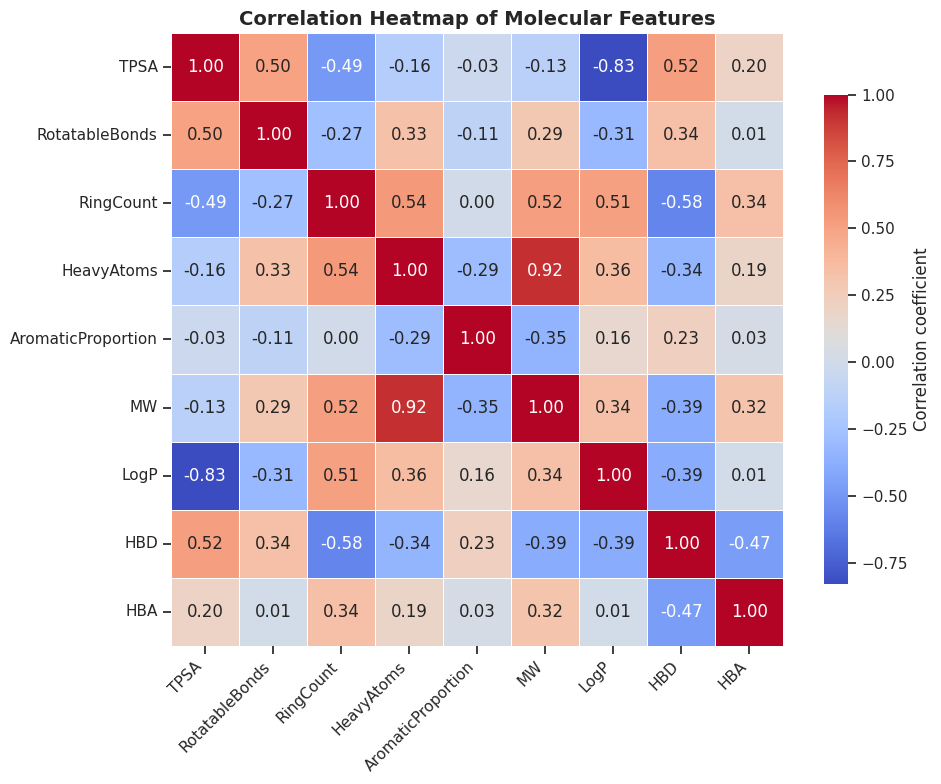

In [43]:
# Features of interest
features = ['TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtoms',
            'AromaticProportion', 'MW', 'LogP', 'HBD', 'HBA']

# Compute correlation matrix
corr = df_combined[features].corr().round(2)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8, "label": "Correlation coefficient"})

plt.title("Correlation Heatmap of Molecular Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Key Observations**:

Strong Positive Correlations:

* MW and HeavyAtoms (r = 0.92): Heavier molecules naturally have more atoms, indicating redundancy.

* MW and RingCount (r = 0.52), and HeavyAtoms and RingCount (r = 0.54): Suggest structurally dense compounds also tend to have more rings.

Strong Negative Correlations:

* TPSA and LogP (r = –0.83): Compounds with higher polarity (TPSA) tend to be less lipophilic, as expected.

* HBD and RingCount (r = –0.58): Molecules with more hydrogen bond donors may tend to have fewer ring structures, reflecting chemical design constraints.

Low or No Correlation:

* AromaticProportion shows little correlation with most features, suggesting it captures a relatively independent aspect of molecular structure.

* RotatableBonds exhibits modest correlations across several features but no strong associations.

This analysis highlights relationships that can guide dimensionality reduction, eliminate redundant features (e.g., MW vs HeavyAtoms), or avoid multicollinearity in predictive models. It also provides chemical insights—for instance, the inverse TPSA–LogP relationship reflects the trade-off between polarity and lipophilicity in drug design.



# DeepChem and ADMETopt

In [44]:
!pip install deepchem

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.1 MB/s eta 0:00:00


In [45]:
import deepchem as dc
import warnings
from rdkit import RDLogger

# Suppress warnings
warnings.filterwarnings("ignore")
RDLogger.DisableLog('rdApp.*')

# 1. Load Tox21 dataset and prepare model
tasks, datasets, transformers = dc.molnet.load_tox21(featurizer='ecfp')
train_dataset, valid_dataset, test_dataset = datasets

model = dc.models.MultitaskClassifier(
    n_tasks=len(tasks),
    n_features=1024,
    layer_sizes=[1000],
    dropouts=[0.25],
    learning_rate=0.001
)

# 2. Train model (adjust nb_epoch as needed)
model.fit(train_dataset, nb_epoch=10)

# 3. Prepare your own molecules from your df (make sure df exists with 'canonical_smiles' column)
your_mols = df["canonical_smiles"].apply(Chem.MolFromSmiles)
valid_idx = your_mols.notnull()
your_mols = your_mols[valid_idx]
valid_smiles = df["canonical_smiles"][valid_idx]

# 4. Featurize your molecules using CircularFingerprint (matches 'ecfp')
featurizer = dc.feat.CircularFingerprint(size=1024)
your_features = featurizer.featurize(your_mols)

# 5. Create dummy labels to satisfy DeepChem's multitask input format
num_samples = your_features.shape[0]
dummy_labels = np.zeros((num_samples, len(tasks)))

# 6. Create a NumpyDataset with features + dummy labels
your_dataset = dc.data.NumpyDataset(X=your_features, y=dummy_labels)

# 7. Predict ADMET (Tox21) properties
preds = model.predict(your_dataset)

# Extract positive class probabilities (class 1)
preds_pos = preds[:, :, 1]

# 8. Store predictions in a DataFrame alongside SMILES
preds_df = pd.DataFrame(preds_pos, columns=tasks)
preds_df["canonical_smiles"] = valid_smiles.values




wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=True, bool includeChirality

In [46]:
display(preds_df)

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,canonical_smiles
0,0.002456,0.008289,0.533871,0.103103,0.081113,0.002682,0.014088,0.003410,0.005340,0.001553,0.054154,0.016577,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(N=[N+...
1,0.004164,0.002629,0.060009,0.072380,0.054258,0.012293,0.002365,0.103603,0.084242,0.003749,0.004082,0.703184,Cc1c(CCC(=O)N2CCCC2)c(=O)n2c([nH]c3ccccc32)c1C#N
2,0.019117,0.000543,0.006584,0.002757,0.308116,0.011736,0.129042,0.186073,0.098182,0.151424,0.177575,0.055655,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(C(F)(F)F...
3,0.014757,0.000339,0.008218,0.008240,0.333840,0.008095,0.024916,0.084435,0.070002,0.045246,0.153617,0.013166,COc1ccc(CNc2nc3cc(C(F)(F)F)ccc3nc2C(=O)O)cc1
4,0.016563,0.000183,0.016966,0.008005,0.148584,0.000818,0.032939,0.210902,0.016736,0.258811,0.260417,0.014240,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(F)cc1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,0.001662,0.000956,0.941958,0.084252,0.577423,0.051403,0.005691,0.179021,0.432622,0.298440,0.442222,0.011161,N#Cc1ccc(C(=O)Nc2sccc2C(=O)NC(=O)OCC2CC2)cc1
143,0.000613,0.002031,0.974036,0.049932,0.238127,0.015515,0.000397,0.039001,0.164270,0.026202,0.051750,0.002784,N#Cc1ccc(C(=O)Nc2sccc2C(=O)NC(=O)OCC2CC2)nc1
144,0.003515,0.000003,0.194298,0.022805,0.549574,0.018141,0.000016,0.103990,0.001184,0.001953,0.049158,0.000166,COC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(S(=O)(=O)N2CCC...
145,0.012606,0.053150,0.241604,0.065612,0.234086,0.000540,0.155388,0.263248,0.164514,0.027115,0.397755,0.197412,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(-n5cc...


##How to interpret each assay result?

Each assay corresponds to a biological target or pathway relevant to toxicity or ADMET properties. Here’s a practical guide:

| Assay         | Interpretation of High Prediction         | Toxicological implication / meaning                                         |
|---------------|-------------------------------------------|---------------------------------------------------------------------------|
| NR-AR         | Likely activates androgen receptor        | Could disrupt hormone signaling, possible endocrine disruption or reproductive toxicity risk |
| NR-AR-LBD     | Likely binds androgen receptor ligand domain | Similar to NR-AR, binding affinity — important for potency               |
| NR-AhR        | Likely activates aryl hydrocarbon receptor | Involved in response to environmental pollutants; activation linked to toxicity & carcinogenesis |
| NR-Aromatase  | Likely inhibits aromatase enzyme           | May disrupt estrogen synthesis, impacting hormone balance                 |
| NR-ER         | Likely activates estrogen receptor         | Potential endocrine disruption, reproductive/developmental toxicity       |
| NR-ER-LBD     | Binding to estrogen receptor ligand domain | Related to binding strength and activity                                  |
| NR-PPAR-gamma | Likely activates PPAR-gamma                 | Can affect metabolism, fat storage, potentially useful or toxic depending on context |
| SR-ARE        | Likely activates antioxidant response element | Could induce detoxifying enzymes, generally protective but can indicate oxidative stress |
| SR-ATAD5      | Likely affects DNA damage response          | Activation could indicate genotoxic stress or DNA repair mechanisms triggered |
| SR-HSE        | Likely activates heat shock response         | Indicates cellular stress response activation                             |
| SR-MMP        | Likely disrupts mitochondrial membrane potential | Sign of mitochondrial toxicity or early apoptosis                       |
| SR-p53        | Likely activates p53 tumor suppressor        | p53 activation often means DNA damage, apoptosis signaling — potential genotoxicity |


In [47]:
# Merge toxicity predictions with bioactivity info
preds_df = preds_df.merge(df_combined[['canonical_smiles', 'bioactivity', 'pIC50']], on='canonical_smiles', how='left')

# Define relevant columns
tox_columns = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase',
    'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

# Create the toxicity index as the sum across selected columns
preds_df['toxicity_index'] = preds_df[tox_columns].sum(axis=1)

# Top 10 most toxic compounds
most_toxic = preds_df.sort_values(by='toxicity_index', ascending=False).head(10)

# Top 10 least toxic compounds
least_toxic = preds_df.sort_values(by='toxicity_index', ascending=True).head(10)

In [48]:
most_potent = preds_df.sort_values(by='pIC50', ascending=False)
most_potent

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,canonical_smiles,bioactivity,pIC50,toxicity_index
132,0.037693,0.014345,0.994785,0.162921,0.847812,0.009162,0.749099,0.533882,0.843848,0.069791,0.899543,0.081532,CCOC(=O)NC(=O)c1ccsc1NC(=O)c1nc2ccccc2s1,active,10.000000,5.244414
160,0.003515,0.000003,0.194298,0.022805,0.549574,0.018141,0.000016,0.103990,0.001184,0.001953,0.049158,0.000166,COC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(S(=O)(=O)N2CCC...,active,10.000000,0.944802
147,0.037693,0.014345,0.994785,0.162921,0.847812,0.009162,0.749099,0.533882,0.843848,0.069791,0.899543,0.081532,CCOC(=O)NC(=O)c1ccsc1NC(=O)c1nc2ccccc2s1,active,10.000000,5.244414
127,0.002706,0.000086,0.198433,0.000699,0.560283,0.000152,0.000737,0.011991,0.011540,0.000907,0.061716,0.000691,CCOC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(C(=O)N2CCCCC2...,active,9.698970,0.849941
126,0.000983,0.000040,0.331534,0.009808,0.718123,0.005230,0.002176,0.058123,0.064588,0.001863,0.053622,0.000943,CCOC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(C(=O)N2CCCCC2...,active,9.522879,1.247033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,0.001806,0.002609,0.779307,0.060608,0.177862,0.016738,0.002688,0.024787,0.129364,0.005099,0.038503,0.001320,CCOC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(C#N)cn1,inactive,4.384681,1.240691
155,0.005708,0.001170,0.566977,0.108835,0.473970,0.062306,0.041332,0.126079,0.377370,0.075053,0.373215,0.005241,CCOC(=O)NC(=O)c1ccsc1NC(=O)c1ccc(C#N)cc1,inactive,4.193820,2.217257
153,0.004136,0.002697,0.999016,0.116027,0.879053,0.006053,0.079748,0.582436,0.682956,0.273682,0.892331,0.079582,O=C(NC(=O)c1ccsc1NC(=O)c1nc2ccccc2s1)OCC1CCCCC1,inactive,4.193820,4.597718
41,0.264833,0.005985,0.123040,0.041984,0.013813,0.001032,0.000192,0.344356,0.001172,0.548838,0.619896,0.027565,CC1(c2ccc(C(=O)O)cc2)NC(=O)N(CC(=O)c2ccc(F)cc2...,inactive,4.100000,1.992705


In [49]:
preds_df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,canonical_smiles,bioactivity,pIC50,toxicity_index
0,0.002456,0.008289,0.533871,0.103103,0.081113,0.002682,0.014088,0.003410,0.005340,0.001553,0.054154,0.016577,C[C@H]1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc(N=[N+...,intermediate,5.017729,0.826637
1,0.004164,0.002629,0.060009,0.072380,0.054258,0.012293,0.002365,0.103603,0.084242,0.003749,0.004082,0.703184,Cc1c(CCC(=O)N2CCCC2)c(=O)n2c([nH]c3ccccc32)c1C#N,active,7.154902,1.106958
2,0.019117,0.000543,0.006584,0.002757,0.308116,0.011736,0.129042,0.186073,0.098182,0.151424,0.177575,0.055655,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(C(F)(F)F...,active,6.920819,1.146805
3,0.014757,0.000339,0.008218,0.008240,0.333840,0.008095,0.024916,0.084435,0.070002,0.045246,0.153617,0.013166,COc1ccc(CNc2nc3cc(C(F)(F)F)ccc3nc2C(=O)O)cc1,active,7.387216,0.764870
4,0.016563,0.000183,0.016966,0.008005,0.148584,0.000818,0.032939,0.210902,0.016736,0.258811,0.260417,0.014240,O=C(O)c1nc2ccc(C(F)(F)F)cc2nc1NCc1ccc(F)cc1,active,7.142668,0.985165


In [50]:
import mols2grid
from rdkit import Chem

# Ensure canonical_smiles is in string format and convert to RDKit Mol objects
most_toxic['mol'] = most_toxic['canonical_smiles'].apply(Chem.MolFromSmiles)
least_toxic['mol'] = least_toxic['canonical_smiles'].apply(Chem.MolFromSmiles)



## Top 10 most toxic compounds

In [51]:
# Use mols2grid to display with toxicity and bioactivity info
mols2grid.display(
    most_toxic,
    smiles_col='canonical_smiles',
    subset=['toxicity_index', 'bioactivity', 'pIC50'],
    tooltip=['toxicity_index', 'bioactivity', 'pIC50'],
    n_cols=5
)


MolGridWidget()

Interestingly, among the top 10 most toxic compounds, 6 are classified as active, 2 as intermediate, and 2 as inactive based on their bioactivity. Notably, two of the active compounds exhibit the highest observed pIC50 value of 10. This raises a critical point: despite their bioactivity, these compounds also show high predicted toxicity, which could severely limit their progression in the drug development pipeline.

While these results are based on in silico predictions and must be interpreted with caution, they highlight an important challenge in drug discovery: balancing potency with safety. If experimentally validated, several of these active yet toxic compounds would likely fail to pass preclinical safety assessments, underscoring the value of early toxicity screening.

## Top 10 least toxic compounds

In [64]:
# Use mols2grid to display with toxicity and bioactivity info
mols2grid.display(
    least_toxic,
    smiles_col='canonical_smiles',
    subset=['toxicity_index', 'bioactivity', 'pIC50'],
    tooltip=['toxicity_index', 'bioactivity', 'pIC50'],
    n_cols=5
)

MolGridWidget()

From these results, we observe that the top 10 least toxic compounds include 2 inactive, 5 intermediate, and 3 active compounds. This distribution contrasts with the trend seen in the top 10 most toxic compounds, where the majority were active. This suggests that lower predicted toxicity does not necessarily correlate with reduced bioactivity and that some compounds may achieve a favorable balance between efficacy and safety.

These findings highlight the importance of identifying compounds that are both active and minimally toxic, which are ideal candidates for further development. Moreover, the presence of active compounds among the least toxic group is encouraging, as it points to the potential of discovering therapeutically effective molecules with safer toxicity profiles.

# Molecule structure and similarity

We can use mols2grid to browse the chemcial structures of the 147 compounds

In [53]:
# Combine the 2 DataFrames
df = pd.concat([df4,df_lipinski], axis=1)
print(df.columns)

Index(['molecule_chembl_id', 'canonical_smiles', 'standard_value',
       'bioactivity', 'TPSA', 'RotatableBonds', 'RingCount', 'HeavyAtoms',
       'AromaticProportion', 'MW', 'LogP', 'HBD', 'HBA'],
      dtype='object')


In [54]:
mols2grid.display(df,smiles_col="canonical_smiles",subset=["img","standard_value"])

MolGridWidget()

Check which parts are common to all molecules.

To do this, we can use the Maxiumum Common Substructure (MCS) capability in the RDKit. To use this, we must first convert the SMILES in our dataframe to RDKit molecule objects. As above, we can use the Pandas apply method to do this.

In [55]:
df['mol'] = df["canonical_smiles"].apply(Chem.MolFromSmiles)

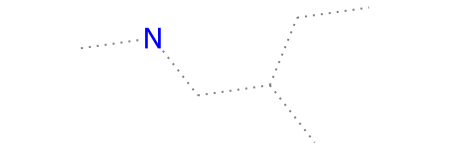

In [56]:
mcs = rdFMCS.FindMCS(df.mol)
pat = Chem.MolFromSmarts(mcs.smartsString)
pat

From this we can observe that the presence of the nitrogen group is important, however, it would be easier if we could map it onto the molecules.

To do this, we can chose the first molecule in the dataframe and display it as a red highlight.

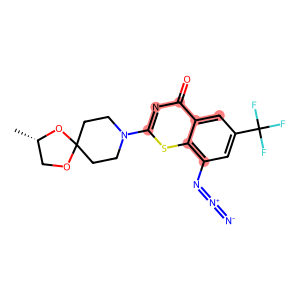

In [57]:
uru.rd_set_image_size(300,300)
df.mol.values[0].GetSubstructMatch(pat)
df.mol.values[0]

From this image we can conclude that the presence of the nitrogen in one or two aromatic rings might be important for the activity

Now we can use the Bemis-Murcko scaffold that is technique that reduces the molecules to a set of connected rings and linkers. It is important to give a perspective of how many different scaffolds exist and how many molecules have those scaffolds.

In [58]:
df['Scaffold'] = df.mol.apply(GetScaffoldForMol)
df['Scaffold_SMILES'] = df.Scaffold.apply(Chem.MolToSmiles)

In [59]:
# Step 1: Count how many of each bioactivity class per scaffold
bioactivity_counts = (
    df.groupby(["Scaffold_SMILES", "bioactivity"])
      .size()
      .unstack(fill_value=0)  # Converts to wide format: one column per label
      .reset_index()
)

# Step 2: Get total scaffold counts using your existing function
scaffold_counts_df = uru.value_counts_df(df, "Scaffold_SMILES")

# Step 3: Merge the two DataFrames
scaffold_summary = scaffold_counts_df.merge(bioactivity_counts, on="Scaffold_SMILES", how="left")

# Step 4: Display the combined result
scaffold_summary


,Scaffold_SMILES,count,active,inactive,intermediate
0,O=C(CN1C(=O)NC(c2ccccc2)C1=O)c1ccccc1,47,32,2,13
1,O=c1nc(N2CCN(CC3CCCCC3)CC2)sc2ccccc12,16,7,2,7
2,c1ccc(CNc2cnc3ccccc3n2)cc1,7,7,0,0
3,O=c1nc(N2CCC3(CC2)OCCO3)sc2c(-n3cccc3)cccc12,5,0,0,5
4,O=C(Nc1cccs1)c1ccc(C(=O)N2CCCCC2)cc1,4,4,0,0
5,O=c1nc(N2CCN(CC3CCCCC3)CC2)sc2c(-n3cccc3)cccc12,3,0,0,3
6,O=C(CN1C(=O)NC(c2ccccc2)C1=O)c1ccccn1,3,2,0,1
7,O=C(CN1C(=O)NC(c2ccccc2)C1=O)c1cccs1,3,3,0,0
8,O=C(CN1C(=O)NC(c2ccccc2)C1=O)c1ccncc1,2,0,1,1
9,O=c1nc(N2CCNCC2)sc2c(-n3cccc3)cccc12,2,0,0,2


In [60]:
mols2grid.display(scaffold_counts_df,smiles_col="Scaffold_SMILES",subset=["img","count"],size=(250,250),
                  n_items_per_page=6)

MolGridWidget()

Let's check the scaffolds that appear only in the inactive compounds

In [61]:
# Group by scaffold and get all unique bioactivity labels per scaffold
bioactivity_per_scaffold = (
    df.groupby('Scaffold_SMILES')['bioactivity']
    .unique()
    .reset_index()
)

# Find scaffolds with only 'inactive' in the list of bioactivities
exclusive_inactive_scaffolds = bioactivity_per_scaffold[
    bioactivity_per_scaffold['bioactivity'].apply(lambda x: set(x) == {'inactive'})
]

print("Scaffolds exclusive to inactive compounds:")
print(exclusive_inactive_scaffolds)



Scaffolds exclusive to inactive compounds:
                                      Scaffold_SMILES bioactivity
4   O=C(CN1C(=O)NC(c2ccc(S(=O)(=O)N3CCOCC3)cc2)C1=...  [inactive]
6   O=C(CN1C(=O)NC(c2ccc(S(=O)(=O)Nc3ccccc3)cc2)C1...  [inactive]
7                  O=C(CN1C(=O)NC(c2ccccc2)C1=O)C1CC1  [inactive]
18            O=C(NC(=O)c1ccsc1NC(=O)c1ccccn1)OCC1CC1  [inactive]
19       O=C(NC(=O)c1ccsc1NC(=O)c1nc2ccccc2s1)OC1CCC1  [inactive]
22     O=C(NC(=O)c1ccsc1NC(=O)c1nc2ccccc2s1)OCC1CCCC1  [inactive]
23    O=C(NC(=O)c1ccsc1NC(=O)c1nc2ccccc2s1)OCC1CCCCC1  [inactive]
28                              O=C(Nc1cccs1)c1ccccc1  [inactive]
29                              O=C(Nc1cccs1)c1ccccn1  [inactive]
37                            O=C1NC(=O)C(c2ccccc2)N1  [inactive]
43        O=c1nc(N2CCCN(S(=O)(=O)C3CC3)CC2)sc2ccccc12  [inactive]
49              O=c1nc(N2CCN(CC3CCCCC3)CC2)sc2ncncc12  [inactive]
50              O=c1nc(N2CCN(CC3CCOCC3)CC2)sc2ccccc12  [inactive]


In [62]:
exclusive_smiles = exclusive_inactive_scaffolds['Scaffold_SMILES']

# Filter counts to only those exclusive inactive scaffolds
filtered_df = scaffold_counts_df[scaffold_counts_df['Scaffold_SMILES'].isin(exclusive_smiles)]

# Display with mols2grid
mols2grid.display(
    filtered_df,
    smiles_col="Scaffold_SMILES",
    subset=["img", "count"],
    size=(250, 250),
    n_items_per_page=6
)

MolGridWidget()

## Zip files

In [63]:
! zip -r results.zip . -i *.csv *.pdf

  adding: bioactivity_preprocessed.csv (deflated 82%)
  adding: tpsa_vs_hbd_hba_heavyatoms.pdf (deflated 29%)
  adding: plot_MW_vs_LogP.pdf (deflated 31%)
  adding: plot_bioactivity_class.pdf (deflated 37%)
  adding: mannwhitney_interpretations.csv (deflated 69%)
  adding: bioactivity_descriptors.csv (deflated 77%)
  adding: rotatable_ringcount_by_bioactivity.pdf (deflated 32%)
  adding: bioactivity_summary_clean.csv (deflated 57%)
  adding: boxplot_pIC50.pdf (deflated 36%)
  adding: bioactivity_data.csv (deflated 92%)
